In [5]:
import matplotlib.pyplot as plt

from power import extract_powers

In [6]:
FILE = './power_vcd.rpt'

In [ ]:
powers = extract_powers(FILE)

[{'group': 'Sequential',
  'internal': 0.0269,
  'switching': 3.58e-05,
  'leakage': 3.19e-06,
  'total': 0.0269,
  'pct': 50.1,
  'is_total': False},
 {'group': 'Combinational',
  'internal': 0.000321,
  'switching': 0.000167,
  'leakage': 8.96e-06,
  'total': 0.000497,
  'pct': 0.9,
  'is_total': False},
 {'group': 'Clock',
  'internal': 0.0179,
  'switching': 0.00686,
  'leakage': 2.24e-06,
  'total': 0.0248,
  'pct': 46.1,
  'is_total': False},
 {'group': 'Macro',
  'internal': 0.0,
  'switching': 0.0,
  'leakage': 0.0,
  'total': 0.0,
  'pct': 0.0,
  'is_total': False},
 {'group': 'Pad',
  'internal': 0.000122,
  'switching': 0.0014,
  'leakage': 1.08e-07,
  'total': 0.00152,
  'pct': 2.8,
  'is_total': False},
 {'group': 'Total',
  'internal': 0.0453,
  'switching': 0.00846,
  'leakage': 1.45e-05,
  'total': 0.0537,
  'pct': 100.0,
  'is_total': True}]

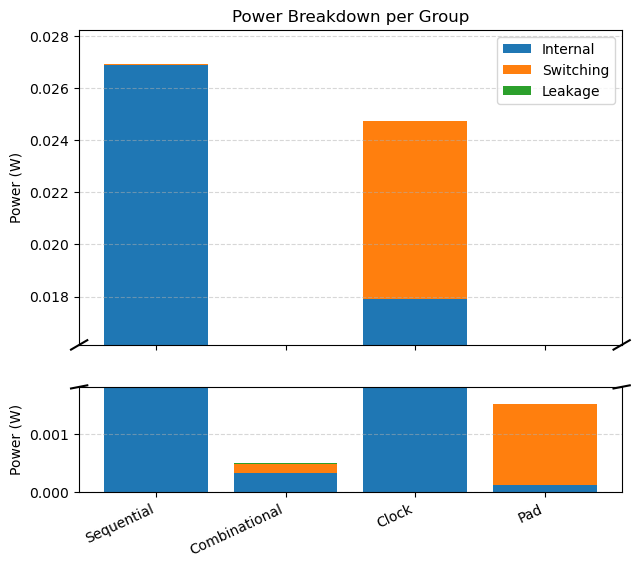

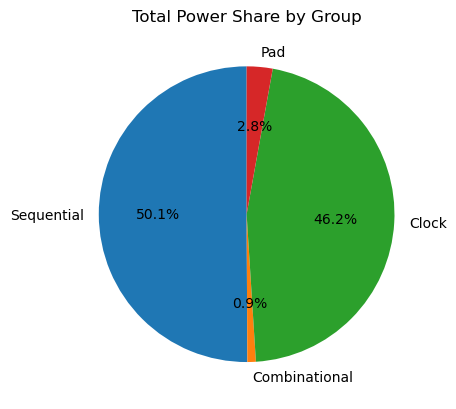

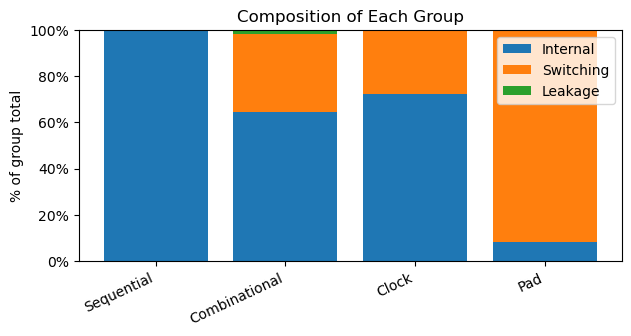

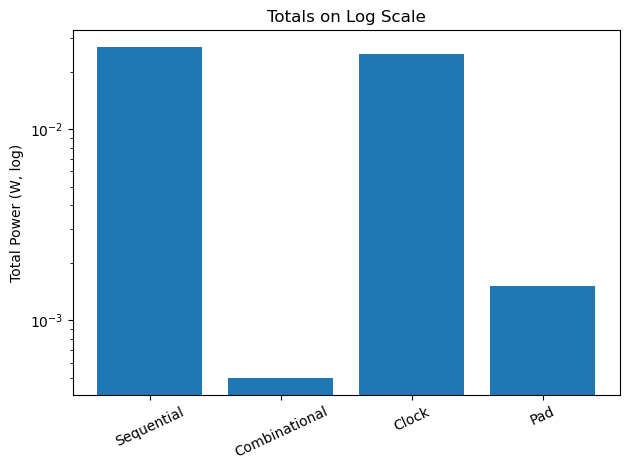

In [16]:
USE_LOG = True  # Set to True to enable log scale plot

main = [r for r in powers if not r["is_total"] and r["total"] > 0]
groups = [r["group"] for r in main]
internal = [r["internal"] for r in main]
switching = [r["switching"] for r in main]
leakage = [r["leakage"] for r in main]
totals = [r["total"] for r in main]

# ===== Stacked bars with broken axis =====
import numpy as np
x = np.arange(len(groups))

fig, (ax_big, ax_small) = plt.subplots(2, 1, sharex=True, figsize=(7,6), gridspec_kw={'height_ratios':[3,1]})
bottoms1 = np.zeros_like(x, dtype=float)
for vals, label in [(internal,"Internal"), (switching,"Switching"), (leakage,"Leakage")]:
    ax_big.bar(x, vals, bottom=bottoms1, label=label)
    ax_small.bar(x, vals, bottom=bottoms1, label=label)
    bottoms1 += vals

# choose breakpoints
hi_min = max(totals)*0.6           # lower bound of upper plot
lo_max = max(v for v in totals if v < hi_min) if any(v < hi_min for v in totals) else hi_min/10

ax_big.set_ylim(hi_min, max(totals)*1.05)
ax_small.set_ylim(0, lo_max*1.2)

# diagonal lines to show the break
d = .015
kwargs = dict(transform=ax_big.transAxes, color='k', clip_on=False)
ax_big.plot((-d,+d), (-d,+d), **kwargs)
ax_big.plot((1-d,1+d), (-d,+d), **kwargs)
kwargs.update(transform=ax_small.transAxes)
ax_small.plot((-d,+d), (1-d,1+d), **kwargs)
ax_small.plot((1-d,1+d), (1-d,1+d), **kwargs)

ax_small.set_ylabel("Power (W)")
ax_small.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)
ax_big.set_ylabel("Power (W)")
ax_big.legend(loc="upper right")
ax_big.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)
ax_big.set_title("Power Breakdown per Group")
ax_small.set_xticks(x)
ax_small.set_xticklabels(groups, rotation=25, ha='right')

# ===== Pie of group totals =====
fig2, ax2 = plt.subplots()
ax2.pie(totals, labels=groups, autopct="%1.1f%%", startangle=90)
ax2.set_title("Total Power Share by Group")

# ===== Percent stacked bar (Internal/Switch/Leakage share of each group) =====
fig3, ax3 = plt.subplots(figsize=(7,3))
stack = np.vstack([internal, switching, leakage])
stack_pct = stack / stack.sum(axis=0)
bottoms2 = np.zeros_like(x, dtype=float)
labels = ["Internal","Switching","Leakage"]
for i, lab in enumerate(labels):
    ax3.bar(x, stack_pct[i], bottom=bottoms2, label=lab)
    bottoms2 += stack_pct[i]
ax3.set_xticks(x)
ax3.set_xticklabels(groups, rotation=25, ha='right')
ax3.set_ylabel("% of group total")
ax3.set_ylim(0,1)
ax3.yaxis.set_major_formatter(lambda v,_: f"{v*100:.0f}%")
ax3.set_title("Composition of Each Group")
ax3.legend()

# ===== Optional: simple log plot =====
if USE_LOG:
    fig4, ax4 = plt.subplots()
    ax4.bar(groups, totals)
    ax4.set_yscale('log')
    ax4.set_ylabel("Total Power (W, log)")
    ax4.set_title("Totals on Log Scale")
    ax4.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()